## Most Optimal Skills for Data Analysts in the Middle East


In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import ast
from datasets import load_dataset

# Loading Data
# Load job postings directly from Hugging Face for reproducibility
ds = load_dataset("lukebarousse/data_jobs")
# Convert training split to a pandas DataFrame
df=ds['train'].to_pandas()


# Data Cleanup
# Convert job_posted_date from string to datetime
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# job_skills is stored as a stringified list — convert it back to an actual Python list
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [2]:
# Define the Middle East country scope
middle_east=['Algeria', 'Bahrain', 'Egypt', 'Iraq', 'Jordan', 'Kuwait', 'Lebanon', 'Libya', 'Morocco', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia', 'Tunisia', 'Turkey', 'United Arab Emirates','Yemen']

# Filter to Data Analyst jobs in the Middle East only
# .copy() avoids SettingWithCopyWarning on later modifications
df_DA_me = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(middle_east))].copy()



In [3]:
# Keep only rows that have salary data — required for median salary calculation
df_DA_me = df_DA_me.dropna(subset=['salary_year_avg'])

# Explode the skills list so each skill gets its own row, paired with the salary of its job
df_DA_me_exploded = df_DA_me.explode('job_skills')
df_DA_me_exploded[['salary_year_avg','job_skills']].head()


,salary_year_avg,job_skills
32311,110000.0,python
32311,110000.0,sql
32311,110000.0,dynamodb
32311,110000.0,gcp
32311,110000.0,aws


In [4]:
# For each skill, compute how often it appears (count) and the median salary of jobs that require it
df_DA_skills = df_DA_me_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count':'skills count', 'median':'median salary'})

# Total number of Data Analyst jobs (before exploding) — used as denominator for skill frequency
job_count = len(df_DA_me)
df_DA_skills['skill precent'] = df_DA_skills['skills count']/ job_count *100

# Only keep skills that appear in more than 11% of job postings to focus on meaningful demand
skill_limit = 11
df_DA_high_demand_skills = df_DA_skills[df_DA_skills['skill precent']>skill_limit ]

df_DA_high_demand_skills


,skills count,median salary,skill precent
job_skills,,,
sql,12,73775.0,70.588235
python,11,72000.0,64.705882
tableau,6,75600.0,35.294118
excel,4,61507.0,23.529412
power bi,4,87025.0,23.529412
r,4,88850.0,23.529412
azure,3,75550.0,17.647059
aws,2,91000.0,11.764706
looker,2,78000.0,11.764706


In [5]:
# Extract the job_type_skills column which maps skills to technology categories (e.g., programming, cloud)
df_tech = df['job_type_skills'].copy()
df_tech = df_tech.drop_duplicates()
df_tech = df_tech.dropna()

# Build a dictionary that maps each technology category to its associated skills
# Each row in df_tech is a stringified dict — parse it and merge values by key
technology_dict = {}
for row in df_tech:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value 
        else:
           technology_dict[key] = value


# Remove duplicate skill entries within each category
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict
    


{'analyst_tools': ['powerbi',
  'msaccess',
  'sap',
  'microstrategy',
  'looker',
  'splunk',
  'outlook',
  'esquisse',
  'sharepoint',
  'nuix',
  'excel',
  'dax',
  'ssrs',
  'datarobot',
  'tableau',
  'qlik',
  'word',
  'ssis',
  'visio',
  'powerpoint',
  'sas',
  'ms access',
  'cognos',
  'alteryx',
  'sheets',
  'power bi',
  'spss',
  'spreadsheet'],
 'programming': ['groovy',
  'shell',
  'crystal',
  'haskell',
  'golang',
  'javascript',
  'ruby',
  'css',
  'objective-c',
  'elixir',
  'r',
  'visualbasic',
  'lua',
  'apl',
  'swift',
  'no-sql',
  'python',
  'sass',
  'java',
  'pascal',
  'perl',
  'c#',
  'kotlin',
  'go',
  'mongo',
  'typescript',
  'fortran',
  'assembly',
  'powershell',
  'bash',
  't-sql',
  'vb.net',
  'html',
  'clojure',
  'rust',
  'f#',
  'dart',
  'cobol',
  'sql',
  'nosql',
  'mongodb',
  'erlang',
  'php',
  'matlab',
  'sas',
  'visual basic',
  'c++',
  'julia',
  'solidity',
  'scala',
  'ocaml',
  'vba',
  'c',
  'delphi',
  'l

In [6]:
# Convert the technology dictionary to a DataFrame for easier merging
df_tech = pd.DataFrame(list(technology_dict.items()),columns = ['technology', 'skills'])

# Explode so each skill gets its own row paired with its technology category
df_tech = df_tech.explode('skills')
df_tech



,technology,skills
0,analyst_tools,powerbi
0,analyst_tools,msaccess
0,analyst_tools,sap
0,analyst_tools,microstrategy
0,analyst_tools,looker
...,...,...
9,sync,google chat
9,sync,rocketchat
9,sync,slack
9,sync,twilio


In [7]:
# Merge high-demand skills with technology categories for use as color coding in the scatter plot
df_plot = df_DA_high_demand_skills.merge(df_tech, left_on='job_skills',right_on='skills')
df_plot



,skills count,median salary,skill precent,technology,skills
0,12,73775.0,70.588235,programming,sql
1,11,72000.0,64.705882,programming,python
2,6,75600.0,35.294118,analyst_tools,tableau
3,4,61507.0,23.529412,analyst_tools,excel
4,4,87025.0,23.529412,analyst_tools,power bi
5,4,88850.0,23.529412,programming,r
6,3,75550.0,17.647059,cloud,azure
7,2,91000.0,11.764706,cloud,aws
8,2,78000.0,11.764706,analyst_tools,looker
9,2,62975.0,11.764706,other,flow


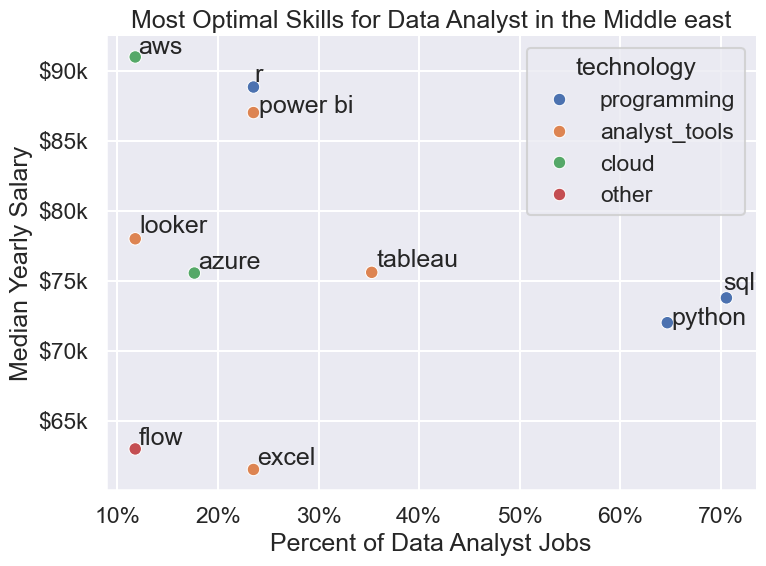

In [9]:
# adjustText helps prevent overlapping skill labels on the scatter plot
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(8, 6))

# Commented-out alternative using plain matplotlib scatter — replaced with seaborn for color coding
# df_plot.plot(
#     kind='scatter',
#     x='skill precent',
#     y='median salary',
#     ax=ax
#     )

sns.set_theme()
sns.set_context("talk")

# Each point represents a skill; x = how often it's required, y = associated median salary
# Color (hue) indicates the technology category of each skill
sns.scatterplot(
    data= df_plot,
    x='skill precent',
    y='median salary',
    hue = 'technology'
                )


# Add skill name labels next to each data point
texts = []
for i, text in enumerate(df_DA_high_demand_skills.index):
    texts.append(ax.text(
        df_DA_high_demand_skills['skill precent'].iloc[i],
        df_DA_high_demand_skills['median salary'].iloc[i],
        text
        ))
    

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analyst in the Middle east')

# Format axes for readability
from matplotlib.ticker import PercentFormatter
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}k'))
# Automatically adjust text positions to minimize label overlaps
adjust_text(texts, ax=ax)

plt.tight_layout()
sns.despine()



## Most Optimal Skills for Data Analysts in the Middle East

Due to the limited number of salary records, the following insights should be interpreted as indicative rather than definitive.

SQL and Python emerge as the most in-demand skills, appearing in the majority of job postings while also offering competitive salary levels. This highlights their importance as foundational skills for Data Analysts.

Visualization tools such as Tableau and Power BI show moderate demand, with Power BI associated with relatively higher median salaries, suggesting added value in business intelligence tools.

Interestingly, some less frequently mentioned skills, such as AWS and R, are linked to higher salary ranges. This may indicate that specialized or advanced skills can lead to better compensation, even if they are not widely required.

On the other hand, Excel remains a commonly requested skill but is associated with lower salary levels, reinforcing its role as a basic rather than differentiating skill.

Overall, the results suggest that combining strong foundational skills (SQL, Python) with selective advanced tools may offer the best balance between demand and earning potential.
